# Week 7 Day 2: Guided Practice - CIFAR-10 Regularization (SOLUTIONS)

**Dataset:** CIFAR-10 (3 classes: airplane, car, bird)
**Time:** 20 minutes (instructor-led)
**Scaffolding:** 70% provided

---

## Goal

Apply Day 1's regularization workflow to **color images** - a harder problem than Fashion-MNIST.

**Workflow:** Load data -> Build baseline -> Diagnose overfitting -> Add regularization -> Compare

---

## Part 1: Setup and Data Loading (Provided)

In [1]:
# Setup (provided)
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(f"Keras version: {keras.__version__}")
print("Setup complete!")

Keras version: 3.13.2
Setup complete!


In [2]:
# Load CIFAR-10 and select 3 classes (provided)
from keras.datasets import cifar10

(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Select 3 classes: 0=airplane, 1=car, 2=bird
selected_classes = [0, 1, 2]
class_names = ['Airplane', 'Car', 'Bird']

# Filter training data
train_mask = np.isin(y_train_full, selected_classes)
X_train_raw = X_train_full[train_mask]
y_train_raw = y_train_full[train_mask]

# Filter test data
test_mask = np.isin(y_test_full, selected_classes)
X_test = X_test_full[test_mask]
y_test = y_test_full[test_mask]

print(f"Training samples: {X_train_raw.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train_raw.shape[1:]} (32x32 color!)")
print(f"Classes: {class_names}")

Training samples: 15000
Test samples: 3000
Image shape: (32, 32, 3) (32x32 color!)
Classes: ['Airplane', 'Car', 'Bird']


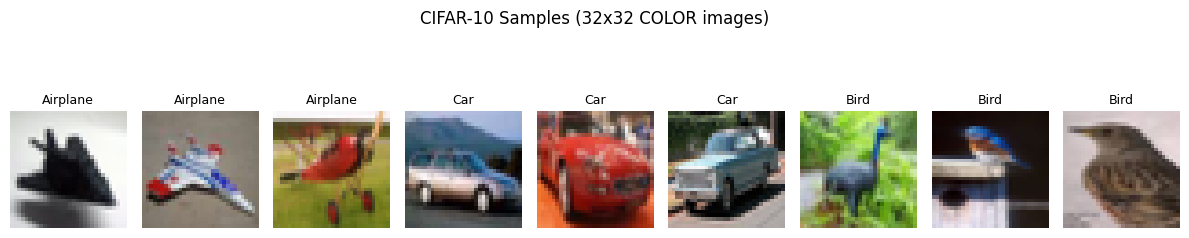


Notice: These are MUCH harder than Fashion-MNIST!
Color images with complex backgrounds and varying poses.


In [3]:
# Visualize some samples (provided)
plt.figure(figsize=(12, 3))
for i, cls in enumerate(selected_classes):
    idx = np.where(y_train_raw == cls)[0][:3]
    for j, sample_idx in enumerate(idx):
        plt.subplot(1, 9, i * 3 + j + 1)
        plt.imshow(X_train_raw[sample_idx])
        plt.title(class_names[i], fontsize=9)
        plt.axis('off')
plt.suptitle('CIFAR-10 Samples (32x32 COLOR images)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nNotice: These are MUCH harder than Fashion-MNIST!")
print("Color images with complex backgrounds and varying poses.")

In [4]:
# Normalize and prepare data (provided)

# Normalize to 0-1
X_train_raw = X_train_raw / 255.0
X_test = X_test / 255.0

# Three-way split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.2, random_state=42, stratify=y_train_raw
)

# Flatten for Dense layers: 32x32x3 = 3072 features
X_train_flat = X_train.reshape(-1, 3072)
X_val_flat = X_val.reshape(-1, 3072)
X_test_flat = X_test.reshape(-1, 3072)

print(f"Training: {X_train_flat.shape}")
print(f"Validation: {X_val_flat.shape}")
print(f"Test: {X_test_flat.shape}")
print(f"\nFeatures per image: {X_train_flat.shape[1]} (vs 784 for Fashion-MNIST!)")

Training: (12000, 3072)
Validation: (3000, 3072)
Test: (3000, 3072)

Features per image: 3072 (vs 784 for Fashion-MNIST!)


---

## Part 2: Build Baseline Model (No Regularization)

**YOUR TASK:** Build a model WITHOUT Dropout to see how badly it overfits.

**Architecture:**
- Input: 3072 features
- Dense: 512 neurons, relu
- Dense: 256 neurons, relu
- Dense: 128 neurons, relu
- Output: 3 neurons, softmax

In [5]:
# SOLUTION: Build baseline model (no Dropout!)

keras.utils.set_random_seed(42)  # reproducible results so the lesson lands consistently

model_baseline = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,987 (6.63 MB)

 Trainable params: 1,737,987 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train baseline (provided - just run this cell)
print("Training baseline model (no regularization)...")
history_baseline = model_baseline.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)
print("\nBaseline training complete!")

Training baseline model (no regularization)...
Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5959 - loss: 0.9421 - val_accuracy: 0.6840 - val_loss: 0.7746
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6896 - loss: 0.7415 - val_accuracy: 0.6853 - val_loss: 0.7662
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7083 - loss: 0.6970 - val_accuracy: 0.7033 - val_loss: 0.7260
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7256 - loss: 0.6560 - val_accuracy: 0.7343 - val_loss: 0.6642
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7460 - loss: 0.6283 - val_accuracy: 0.7400 - val_loss: 0.6395
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7508 - loss: 0.6096 - val_accuracy: 0.7527 - val_loss: 0.6259
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7617 - loss: 0.5769 - val_accuracy: 0.7653 - val_loss: 0.6029
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7662 -

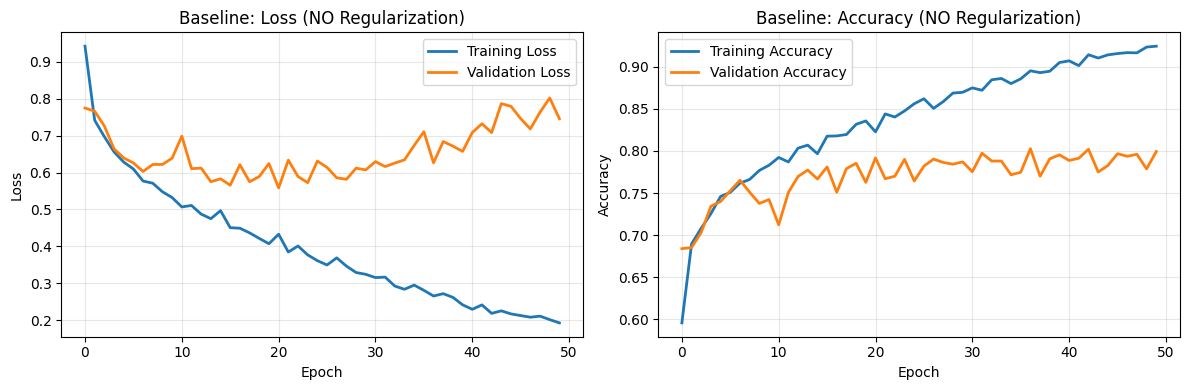

Training Accuracy: 0.9243
Validation Accuracy: 0.7993
Gap: 0.1250


In [7]:
# Plot baseline curves (provided)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Baseline: Loss (NO Regularization)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Baseline: Accuracy (NO Regularization)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

train_acc = history_baseline.history['accuracy'][-1]
val_acc = history_baseline.history['val_accuracy'][-1]
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Gap: {(train_acc - val_acc):.4f}")

### PAUSE HERE - Discuss with Instructor

**Questions to answer:**
1. What pattern do you see in the curves?
2. How does the gap compare to what you saw with Fashion-MNIST on Day 1?
3. Why might CIFAR-10 overfit MORE than Fashion-MNIST?

**Sample answers:**
1. Classic overfitting: training accuracy keeps climbing (to ~92% by epoch 50) while validation accuracy plateaus around ~80%. The curves separate clearly after the first several epochs, and validation loss starts creeping back up.
2. The gap (~12-13 percentage points) is larger than the Fashion-MNIST gap from Day 1 - the grayscale, centered Fashion-MNIST images generalize more easily.
3. Color images (3x more features: 3072 vs 784), cluttered backgrounds, objects at varying poses/scales - a bird and an airplane can look similar from some angles.

---

## Part 3: Build Regularized Model

**YOUR TASK:** Add Dropout layers and configure EarlyStopping to fix the overfitting.

**Architecture (same as baseline + Dropout):**
- Input: 3072 features
- Dense: 512 neurons, relu
- **Dropout: 0.2**
- Dense: 256 neurons, relu
- **Dropout: 0.2**
- Dense: 128 neurons, relu
- **Dropout: 0.2**
- Output: 3 neurons, softmax

> **Why 0.2 and not 0.3?** On this small Dense network, dropping 30% of units over-regularizes and the model *underfits* (training AND validation accuracy fall). 0.2 cuts the overfitting gap while keeping accuracy. The dropout rate is a hyperparameter you tune - not a fixed magic number.

In [8]:
# SOLUTION: Build regularized model (add Dropout after each Dense layer)

keras.utils.set_random_seed(42)  # same seed as baseline -> apples-to-apples comparison

model_regularized = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

model_regularized.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Regularized model built!")
model_regularized.summary()

Regularized model built!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,987 (6.63 MB)

 Trainable params: 1,737,987 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# SOLUTION: Configure EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

print("EarlyStopping configured!")

EarlyStopping configured!


In [10]:
# SOLUTION: Train regularized model with EarlyStopping

print("Training regularized model...")
history_regularized = model_regularized.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
print("\nRegularized training complete!")

Training regularized model...
Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5008 - loss: 1.0590 - val_accuracy: 0.6610 - val_loss: 0.8347
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6554 - loss: 0.8107 - val_accuracy: 0.6887 - val_loss: 0.7581
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6779 - loss: 0.7613 - val_accuracy: 0.6777 - val_loss: 0.7760
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7002 - loss: 0.7314 - val_accuracy: 0.7087 - val_loss: 0.7177
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7149 - loss: 0.7031 - val_accuracy: 0.6800 - val_loss: 0.7290
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7190 - loss: 0.6886 - val_accuracy: 0.7273 - val_loss: 0.6627
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7216 - loss: 0.6770 - val_accuracy: 0.7190 - val_loss: 0.6906
Epoch 8/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7140 - loss: 0.6853 - 

---

## Part 4: Compare Results

**YOUR TASK:** Plot both models side-by-side and analyze the improvement.

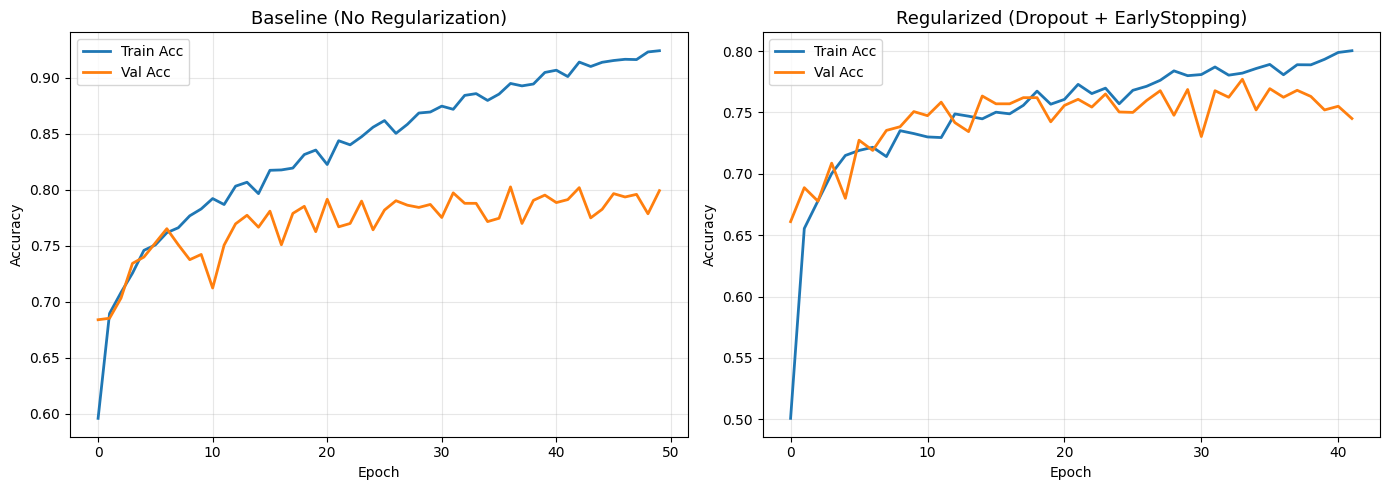

In [11]:
# Side-by-side comparison (provided)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline curves
axes[0].plot(history_baseline.history['accuracy'], label='Train Acc', linewidth=2)
axes[0].plot(history_baseline.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[0].set_title('Baseline (No Regularization)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Regularized curves
axes[1].plot(history_regularized.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_regularized.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_title('Regularized (Dropout + EarlyStopping)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Quantitative comparison (provided)
baseline_train = history_baseline.history['accuracy'][-1]
baseline_val = history_baseline.history['val_accuracy'][-1]
baseline_gap = baseline_train - baseline_val

# EarlyStopping restored the BEST weights (lowest val_loss), which is usually NOT
# the final epoch. Report metrics from that restored epoch for a fair comparison.
best_epoch = int(np.argmin(history_regularized.history['val_loss']))
reg_train = history_regularized.history['accuracy'][best_epoch]
reg_val = history_regularized.history['val_accuracy'][best_epoch]
reg_gap = reg_train - reg_val

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<25} {'Baseline':>10} {'Regularized':>12}")
print("-" * 50)
print(f"{'Training Accuracy':<25} {baseline_train:>10.4f} {reg_train:>12.4f}")
print(f"{'Validation Accuracy':<25} {baseline_val:>10.4f} {reg_val:>12.4f}")
print(f"{'Gap (overfit indicator)':<25} {baseline_gap:>10.4f} {reg_gap:>12.4f}")
print("-" * 50)
print(f"{'Epochs Trained':<25} {len(history_baseline.history['loss']):>10} {len(history_regularized.history['loss']):>12}")
print(f"{'Gap Reduction':<25} {'':<10} {((baseline_gap - reg_gap) / baseline_gap * 100):>11.1f}%")
print("=" * 50)

MODEL COMPARISON
Metric                      Baseline  Regularized
--------------------------------------------------
Training Accuracy             0.9243       0.7820
Validation Accuracy           0.7993       0.7770
Gap (overfit indicator)       0.1250       0.0050
--------------------------------------------------
Epochs Trained                    50           42
Gap Reduction                               96.0%


In [13]:
# Final test evaluation (provided)
test_loss, test_acc = model_regularized.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Validation Accuracy: {reg_val:.4f}")
print(f"Test-Val Difference: {abs(test_acc - reg_val):.4f}")


Final Test Accuracy: 0.7880
Validation Accuracy: 0.7770
Test-Val Difference: 0.0110


---

## Discussion Questions

**Answer with your neighbor or as a class:**

1. **How did CIFAR-10 overfitting compare to Fashion-MNIST?**
   - Bigger gap. The baseline reached ~92% training accuracy but only ~80% validation (a ~12-13 pt gap), wider than Day 1's Fashion-MNIST gap. More features (3072 vs 784) and more visual complexity make the training set easier to memorize.

2. **Did the same regularization techniques work?**
   - Yes - the *tools* transfer, but you tune the *settings*. Dropout + EarlyStopping cut the train/val gap from ~12.5 pts to under 1 pt (~96% reduction) while holding validation accuracy steady (~80% -> ~78%) and reaching ~79% on the test set. The catch: we used Dropout **0.2**, not 0.3 - on this small Dense network 0.3 over-regularizes and *underfits* (both train and val accuracy drop). The dropout rate is a knob you tune to the model and dataset, not a fixed number.

3. **Why is CIFAR-10 harder than Fashion-MNIST?**
   - 3 color channels (vs 1 grayscale), cluttered backgrounds, objects at different angles/scales, and more within-class variation. Dense networks treat each pixel independently and can't exploit spatial structure - CNNs (Week 8) handle images far better.

---

*Week 7 Day 2 Guided Practice SOLUTIONS | Version 1.0 | March 2026*